In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [3]:
# Create a dataset

# Set random seed
np.random.seed(42)

# Number of samples
num_samples = 550

# Generate normal distributed CGPA around 7.0 with std deviation 1.0
cgpa = np.clip(np.random.normal(7.0, 1.0, num_samples), 5.0, 10.0)

# Generate normal distributed Score around 500 with std deviation 100
score = np.clip(np.random.normal(500, 100, num_samples), 200, 800)

# Linear rule: if (CGPA * 10 + Score) > 1200 → Placed = 1
placed = []
for i in range(num_samples):
    decision_boundary = cgpa[i]*10 + score[i]
    if decision_boundary> 600:
        placed.append(1)
    else:
        placed.append(0)


# Create DataFrame
dataset = pd.DataFrame({
    'CGPA': cgpa,
    'Score': score,
    'Placed': placed
})

# Show a sample
dataset.head()

,CGPA,Score,Placed
0,7.496714,508.658979,0
1,6.861736,484.432276,0
2,7.647689,616.778206,1
3,8.523030,525.442084,1
4,6.765847,533.760266,1


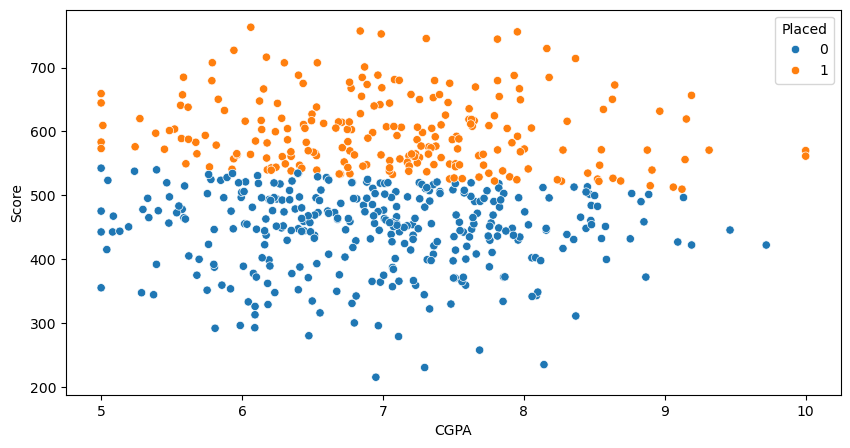

In [6]:
# plt the graph

plt.figure(figsize=(10,5))
sns.scatterplot(x='CGPA', y='Score', data=dataset, hue='Placed')
plt.show()

In [7]:
#input and output 

x = dataset.iloc[:, :-1]
y = dataset['Placed']

In [8]:
# train test split

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Now use the Perceptron

In [9]:
from sklearn.linear_model import Perceptron

In [ ]:
# train the model
pr = Perceptron()
pr.fit(x_train, y_train)

Perceptron()

In [12]:
# check the accuracy
pr.score(x_test, y_test), pr.score(x_train, y_train)

(0.36363636363636365, 0.425)

d:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


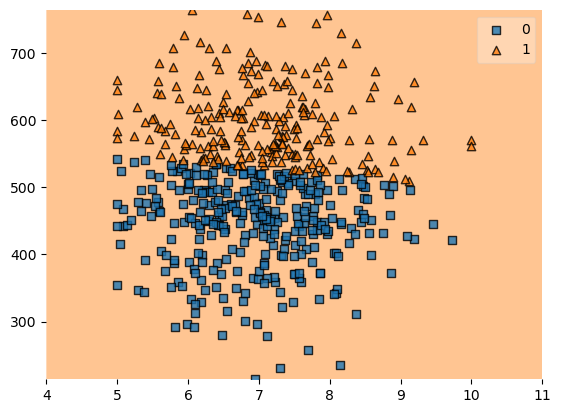

In [13]:
# plot the decision region

plot_decision_regions(x.to_numpy(), y.to_numpy(), clf= pr)
plt.show()

## Hyperparameters Tuning to increase accuracy

In [16]:
pr2 = Perceptron(alpha=0.01, max_iter=1000, tol=1e-3)
pr2.fit(x_train, y_train)

Perceptron(alpha=0.01)

In [17]:
pr.score(x_test, y_test), pr2.score(x_train, y_train)

(0.36363636363636365, 0.425)

In [18]:
# Now you could see that there is no difference in the accuracy of the model, thats why we are not using the Single Layer Perceptron